# Voxel Volumes to Surface Meshes

This notebook converts 3D voxel volumes (labelmaps/masks/intensity) into polygonal meshes. We start with **PyVista** (VTK-powered, convenient), then dive into a **native VTK** pipeline. 

In [2]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import tifffile as tiff
import pyvista as pv
from vtk.util import numpy_support as vtk_np
from skimage import measure
from pathlib import Path
from skimage import filters, measure
from scipy.ndimage import gaussian_filter
import os

In [3]:
vol = tiff.imread(Path("../example_data") / "t1-head.tif")
spacing = [1.0, 1.0, 1.0]
vol.shape, vol.dtype, float(vol.min()), float(vol.max())

((129, 256, 256), dtype('<u2'), 0.0, 885.0)

In [4]:
output_dir = Path('results') / 'voxel_to_mesh'
output_dir.mkdir(exist_ok=True, parents=True)

## PyVista workflow (VTK under the hood)
**Steps:** extract → (optional) smooth → (optional) decimate → export STL/PLY → save a screenshot.

Use `contour(isosurfaces=[level])` and set `grid.spacing` for correct units.

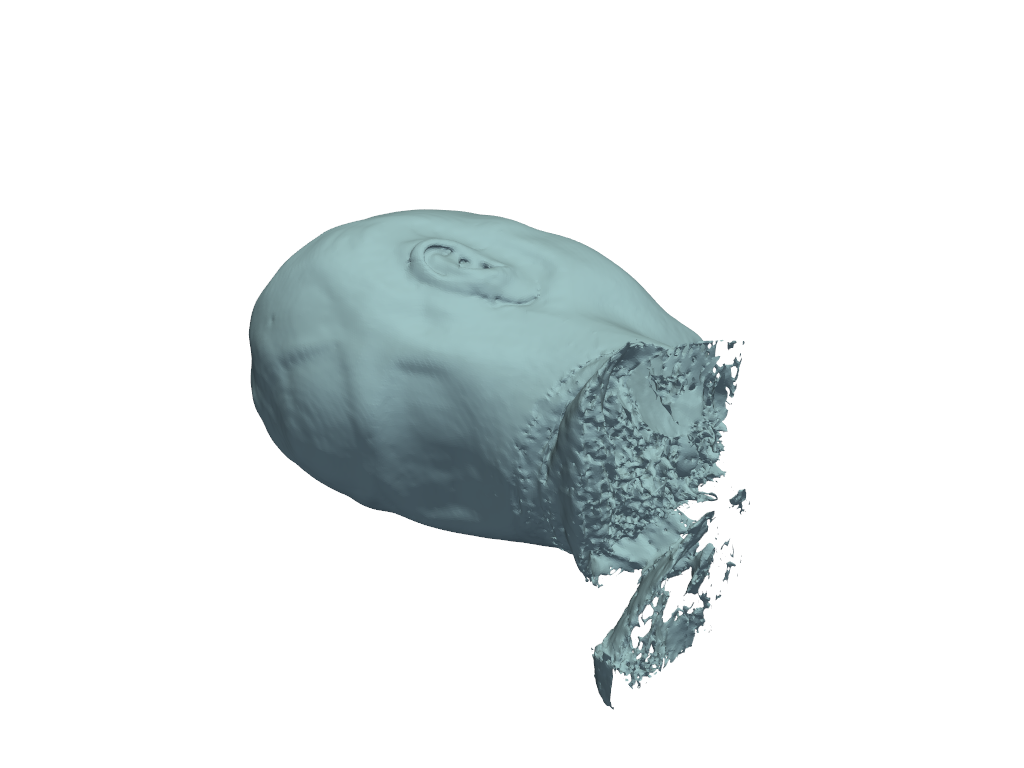

In [9]:
# Wrap the numpy volume into ImageData
grid = pv.ImageData()
grid.dimensions = vol.shape[::-1]  # X, Y, Z
# grid.spacing = spacing[::-1]       # dx, dy, dz
grid.point_data['values'] = vol.ravel(order='C')

# Extract isosurface
level = 80
surf = grid.contour(isosurfaces=[level], scalars='values', method='flying_edges')

# Mesh moothing
surf_sm = surf.smooth(n_iter=30, relaxation_factor=0.1)

# Mesh decimation
surf_dec = surf_sm.decimate(target_reduction=0.9, inplace=False)

# Exports
# surf_dec.save(output_dir / 'mesh_channel2.stl')
# surf_dec.save(output_dir / 'mesh_channel2.ply')
# print('Saved: mesh_pyvista.stl and mesh_pyvista.ply')

# Take screenshot
pl = pv.Plotter(off_screen=True)
pl.add_mesh(surf_dec)
pl.set_background('white')
pl.show(screenshot=output_dir / 'pyvista_preview.png', auto_close=True, jupyter_backend="static")

## Why pad the data (border effects)
When an object touches the volume boundary, isosurface extraction can produce **open surfaces** (missing caps). Padding adds a thin border of zeros so the surface closes properly.

**Demo:** We create two small volumes with a sphere touching the border vs. a padded version, then extract surfaces.

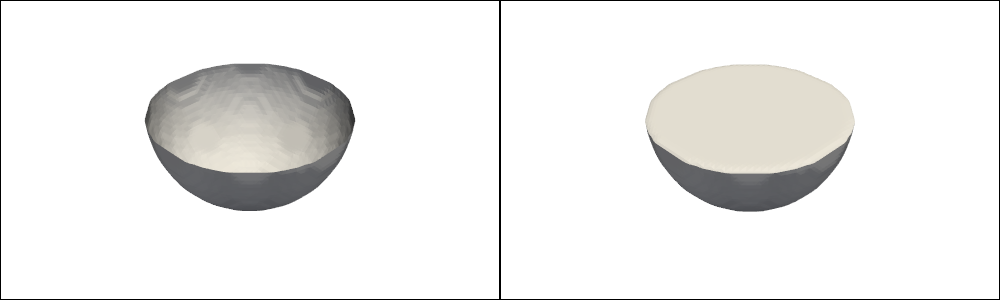

In [9]:
shape2 = (64,64,64)
zz, yy, xx = np.mgrid[0:shape2[0], 0:shape2[1], 0:shape2[2]]
center = np.array([32, 32, 64])  # touches X-min border
r = 24
vol_touch = (((zz-center[0])**2 + (yy-center[1])**2 + (xx-center[2])**2) <= (r*r)).astype(np.float32)
vol_touch = gaussian_filter(vol_touch.astype(np.float32), sigma=1.0)
spacing2 = (1.0,1.0,1.0)

# Padded version
vol_pad = np.pad(vol_touch, ((1,1),(1,1),(1,1)), 'constant', constant_values=0)
spacing_pad = spacing2

pl = pv.Plotter(off_screen=True, shape=(1,2), window_size=(1000, 300))
pl.set_background('white')

def preview_volume_isosurface(volume, spacing, pl, i):
    grid = pv.ImageData()
    grid.dimensions = volume.shape[::-1]
    grid.spacing = spacing[::-1]
    grid.point_data['values'] = volume.ravel(order='F')
    surf = grid.contour(isosurfaces=[0.5], scalars='values')
    pl.subplot(0, i)
    pl.add_mesh(surf, color="white")

preview_volume_isosurface(vol_touch, spacing2, pl, 0)
preview_volume_isosurface(vol_pad, spacing_pad, pl, 1)

pl.show(jupyter_backend="static")

**Takeaway:** If your objects can touch the edges of the volume, **pad with a few voxels of background** before running isosurface extraction.

## 8. Impact of decimation (triangle reduction)
Decimation reduces triangle count to shrink file size and speed up downstream tools. Too much decimation can oversimplify and lose details. Below we compare different reduction targets.

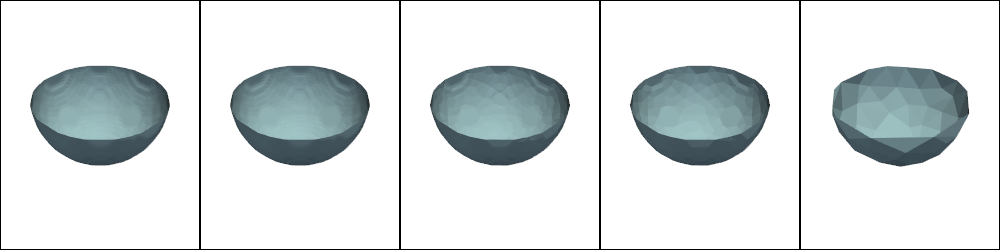

Triangle/size summary (reduction: (triangles, file_kB)): {0.0: (10356, 505.74609375), 0.5: (5178, 252.9140625), 0.9: (1034, 50.5703125), 0.95: (516, 25.27734375), 0.99: (102, 5.0625)}


In [10]:
reduction_steps = [0.0, 0.5, 0.9, 0.95, 0.99]

# create image data from numpy array
grid = pv.ImageData()
grid.dimensions = vol_touch.shape[::-1]
grid.spacing = spacing[::-1]
grid.point_data['values'] = vol_touch.ravel(order='F')

# convert image data to mesh
base = grid.contour(isosurfaces=[0.5], scalars='values')

counts = {}
pl = pv.Plotter(off_screen=True, shape=(1,5), window_size=(1000, 250))
pl.set_background('white')
for i, red in enumerate(reduction_steps):

    # decimate mesh geometry
    mesh = base.decimate(target_reduction=red, inplace=False)

    # save mesh as STL and PNG
    out_stl = f'decim_{int(red*100)}.stl'
    out_png = f'decim_{int(red*100)}.png'
    mesh.save(output_dir / out_stl)
    
    tri_count = mesh.n_cells
    size_kb = os.path.getsize(output_dir / out_stl)/1024.0
    counts[red] = (tri_count, size_kb)
    pl.subplot(0, i)
    pl.add_mesh(mesh)
pl.show(screenshot=output_dir / out_png, jupyter_backend="static")
print('Triangle/size summary (reduction: (triangles, file_kB)):', counts)


## 9. Binary vs. non-binary marching cubes
Marching cubes on a **binary mask** (0/1) yields surfaces tightly fitted to thresholded objects. On a **grayscale/probability** volume, the surface depends on the chosen **isovalue** and will have subpixel resolution.

**Demo:** Compare (a) marching cubes on the smoothed grayscale volume to (b) threshold to binary first, then marching cubes.

Non-binary marching cubes: verts=5273, faces=10356
Binary (Otsu thr=0.459) marching cubes: verts=5273, faces=10356


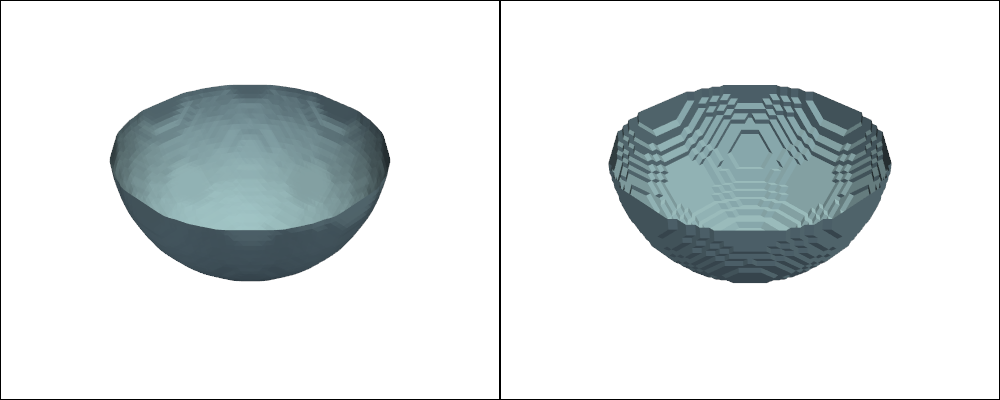

In [11]:
pl = pv.Plotter(off_screen=True, shape=(1,2), window_size=(1000, 400))

# (a) marching cubes on non-binary volume
verts, faces, _, _ = measure.marching_cubes(vol_touch, level=0.5, spacing=(1.0,1.0,1.0))
mesh = pv.PolyData(verts, faces=np.hstack([np.full((faces.shape[0],1),3), faces]).ravel())
pl.subplot(0, 0)
pl.add_mesh(mesh)
pl.set_background('white')
print(f'Non-binary marching cubes: verts={verts.shape[0]}, faces={faces.shape[0]}')

# (b) Binary first (Otsu threshold)
thr = float(filters.threshold_otsu(vol_touch))
binv = (vol_touch >= thr).astype(np.float32)
# marching cube on binary volume
verts, faces, _, _ = measure.marching_cubes(binv, level=0.5, spacing=(1.0,1.0,1.0))
mesh = pv.PolyData(verts, faces=np.hstack([np.full((faces.shape[0],1),3), faces]).ravel())
pl.subplot(0, 1)
pl.add_mesh(mesh)
pl.set_background('white')
print(f'Binary (Otsu thr={thr:.3f}) marching cubes: verts={verts.shape[0]}, faces={faces.shape[0]}')

pl.show(screenshot=output_dir / 'non-binary-vs-binary-marching-cubes.png', jupyter_backend="static")